In [57]:
import numpy as np
import pandas as pd

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer


In [58]:
df = pd.read_csv('Titanic-Dataset.csv', usecols = ['Age','Fare','Survived'])

In [59]:
df.head(1)

,Survived,Age,Fare
0,0,22.0,7.25


In [60]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [61]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [62]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [63]:
df.head(1)

,Survived,Age,Fare
0,0,22.0,7.25


In [64]:
X = df.iloc[:,1:3] # Age & fare
y = df.iloc[:,0] # Output col
# X = df[['Age','Fare']]   # input features
# y = df['Survived']       # target

In [65]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

C:\Users\MY PC\AppData\Local\Temp\ipykernel_25812\2869112033.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'])


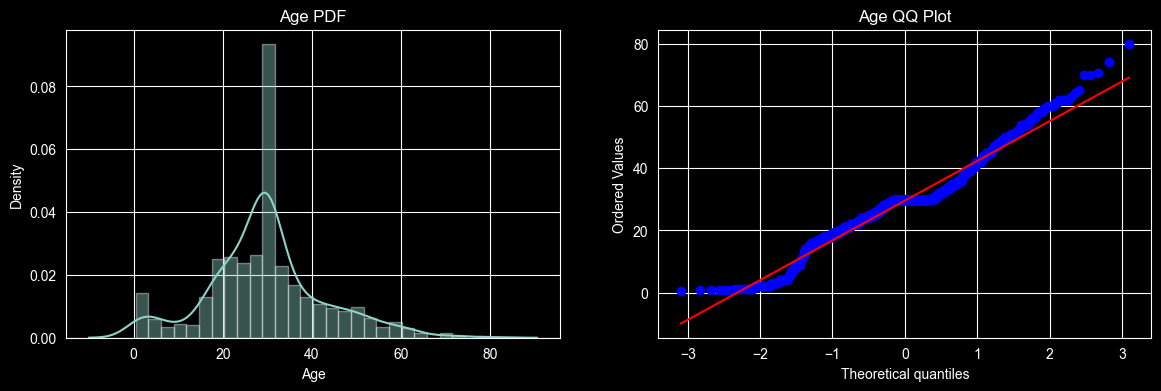

In [66]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['Age'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Age'], dist='norm', plot=plt)
plt.title('Age QQ Plot')

plt.show()

C:\Users\MY PC\AppData\Local\Temp\ipykernel_25812\109985689.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_test['Fare'])


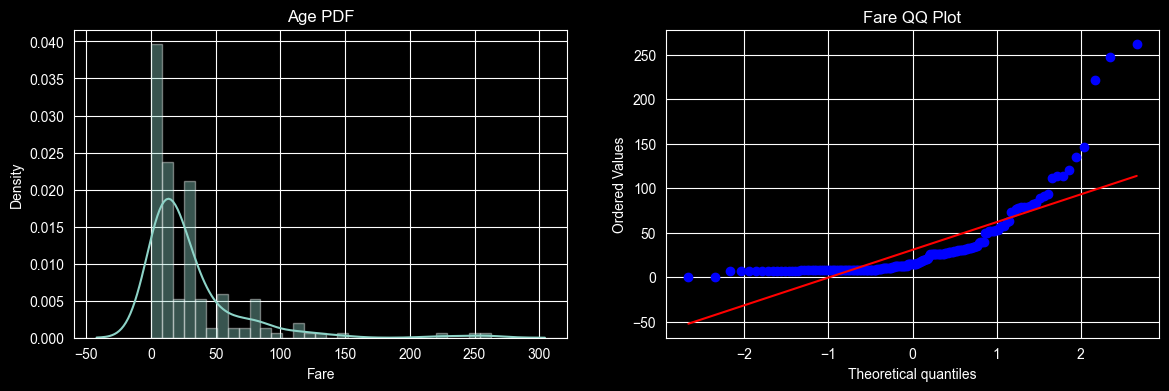

In [67]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_test['Fare'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_test['Fare'], dist='norm', plot=plt)
plt.title('Fare QQ Plot')

plt.show()

In [68]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [69]:
# X_train = X_train.values
# X_test = X_test.values
# y_train = y_train.values
# y_test = y_test.values

In [70]:
clf.fit(X_train, y_train)
clf2.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_pred1 = clf2.predict(X_test)

print("Accuracy LogisticRegression:", accuracy_score(y_test, y_pred))
print("Accuracy DecisionTree:", accuracy_score(y_test, y_pred1))

Accuracy LogisticRegression: 0.6480446927374302
Accuracy DecisionTree: 0.6703910614525139


In [71]:
trf = FunctionTransformer(func=np.log1p)

In [72]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [73]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed, y_train)
clf2.fit(X_train_transformed, y_train)

y_pred = clf.predict(X_test_transformed)
y_pred1 = clf2.predict(X_test_transformed)

print("Accuracy LogisticRegression:", accuracy_score(y_test, y_pred))
print("Accuracy DecisionTree:", accuracy_score(y_test, y_pred1))

Accuracy LogisticRegression: 0.6815642458100558
Accuracy DecisionTree: 0.664804469273743


In [74]:
X_transformed = trf.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print('LR', np.mean(cross_val_score(clf, X_transformed,y, scoring='accuracy', cv=10)))

print('DT', np.mean(cross_val_score(clf2,X_transformed,y, scoring='accuracy', cv=10)))

LR 0.678027465667915
DT 0.658876404494382


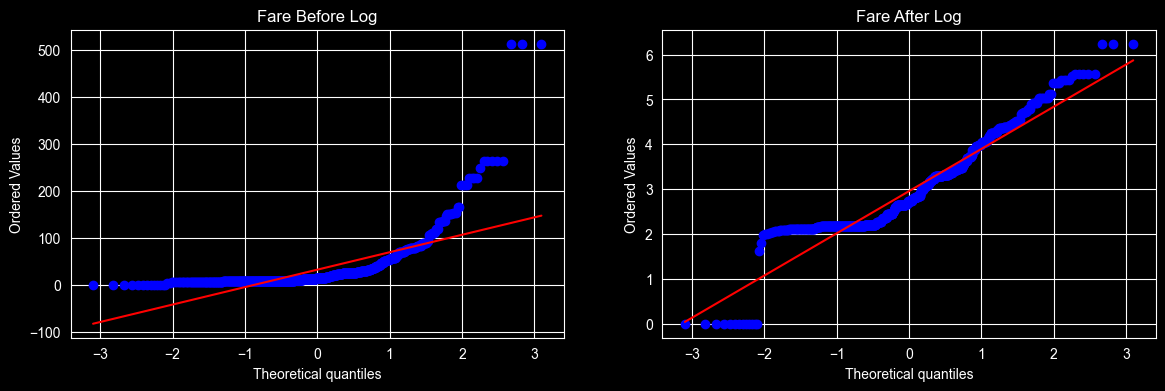

In [75]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'], dist="norm", plot=plt)
plt.title('Fare After Log')

plt.show()

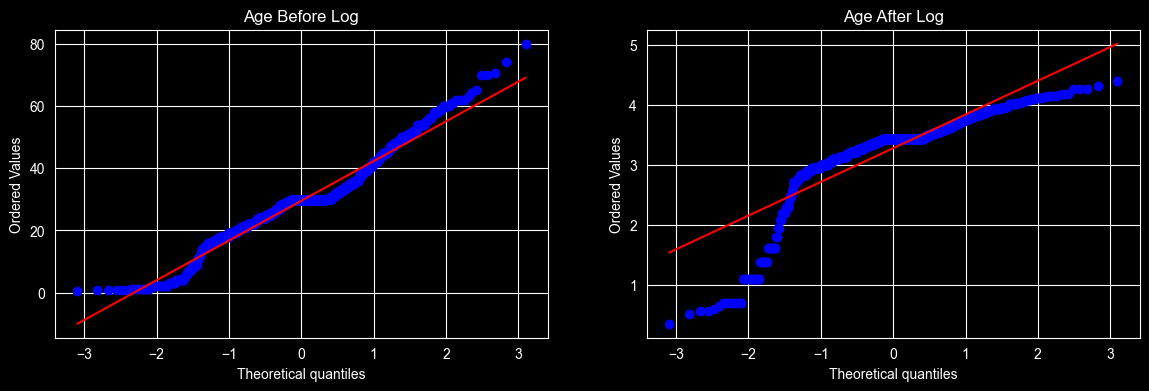

In [76]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age Before Log')

plt.subplot(122)
stats.probplot(X_train_transformed['Age'], dist="norm", plot=plt)
plt.title('Age After Log')

plt.show()

In [77]:
trf2 = ColumnTransformer([('log', FunctionTransformer(np.log1p), ['Fare'])], remainder='passthrough')
X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.transform(X_test)

In [78]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2, y_train)
clf2.fit(X_train_transformed2, y_train)

y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)

print("Accuracy LogisticRegression:", accuracy_score(y_test, y_pred))
print("Accuracy DecisionTree:", accuracy_score(y_test, y_pred2))

Accuracy LogisticRegression: 0.6703910614525139
Accuracy DecisionTree: 0.6927374301675978


In [79]:
X_transformed2 = trf2.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print('LR', np.mean(cross_val_score(clf, X_transformed2,y, scoring='accuracy', cv=10)))

print('DT', np.mean(cross_val_score(clf2,X_transformed2,y, scoring='accuracy', cv=10)))


LR 0.6712609238451936
DT 0.6565917602996254


In [82]:
def apply_transform(transform):
    X = df[['Age','Fare']]
    y = df['Survived']

    trf = ColumnTransformer(
        [('log', FunctionTransformer(transform), ['Fare'])],
        remainder='passthrough'
    )

    X_trans = trf.fit_transform(X)

    clf = LogisticRegression()

    print('Accuracy:', np.mean(cross_val_score(clf, X_trans, y, scoring='accuracy', cv=10)))

    plt.figure(figsize=(14,4))

    # Before transform
    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    # After transform
    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()

Accuracy: 0.616167290886392


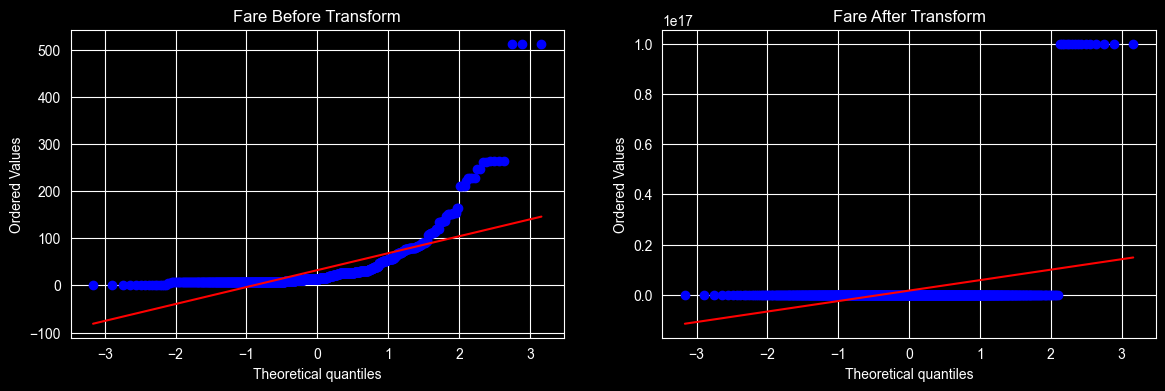

In [91]:
apply_transform(lambda x: 1/(x+0.00000000000000001))